## Phase 0: Setup

In [ ]:
!pip install -q vaderSentiment datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os, re, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from datasets import load_dataset
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
os.makedirs("outputs", exist_ok=True)
SEED = 42
np.random.seed(SEED)

def save(name):
    """Save the current figure to outputs/ and display it."""
    plt.tight_layout()
    plt.savefig(f"outputs/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def metrics(y_true, pred):
    return {"Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred)}

## Phase 1: Load the data and protect the test set

In [ ]:
ds = load_dataset("stanfordnlp/imdb")
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()
print("Raw sizes  -> train:", len(train_df), "| test:", len(test_df))

train_df = train_df.drop_duplicates(subset="text").reset_index(drop=True)
test_df = test_df.drop_duplicates(subset="text").reset_index(drop=True)
print("After removing duplicates inside each set -> train:", len(train_df), "| test:", len(test_df))

overlap = set(train_df["text"]) & set(test_df["text"])
print("Reviews present in BOTH train and test:", len(overlap))
test_df = test_df[~test_df["text"].isin(overlap)].reset_index(drop=True)
print("Final sizes -> train:", len(train_df), "| test:", len(test_df))

print("\nTrain class counts:\n", train_df["label"].value_counts().sort_index())
print("\nTest class counts:\n", test_df["label"].value_counts().sort_index())

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Raw sizes  -> train: 25000 | test: 25000
After removing duplicates inside each set -> train: 24904 | test: 24801
Reviews present in BOTH train and test: 123
Final sizes -> train: 24904 | test: 24678

Train class counts:
 label
0    12432
1    12472
Name: count, dtype: int64

Test class counts:
 label
0    12266
1    12412
Name: count, dtype: int64


## Phase 2: Text preparation


In [ ]:
lemmatizer = WordNetLemmatizer()
NEGATIONS = {"no", "nor", "not", "never", "neither", "none", "nothing", "nowhere", "hardly", "barely"}
STOP = set(stopwords.words("english")) - NEGATIONS
CONTRACTIONS = [
    (r"won't", "will not"), (r"can't", "can not"), (r"cannot", "can not"), (r"shan't", "shall not"),
    (r"n't", " not"), (r"'re", " are"), (r"'ve", " have"), (r"'ll", " will"),
    (r"'d", " would"), (r"'m", " am"), (r"'s", ""),
]

def strip_html(t):
    return re.sub(r"<[^>]+>", " ", t)

def strip_urls(t):
    return re.sub(r"http\S+|www\.\S+", " ", t)

def expand_contractions(t):
    t = t.replace("\u2019", "'")
    for pat, rep in CONTRACTIONS:
        t = re.sub(pat, rep, t)
    return t

def keep_alpha(t):
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def remove_stop(t):
    return " ".join(w for w in t.split() if w not in STOP and len(w) > 1)

def lemmatize(t):
    return " ".join(lemmatizer.lemmatize(w) for w in t.split())

def light_clean(t):
    return expand_contractions(strip_urls(strip_html(t)).lower())

def full_clean(light_text):
    return lemmatize(remove_stop(keep_alpha(light_text)))

# takes 1-3 minutes
for d in (train_df, test_df):
    d["light"] = d["text"].map(light_clean)
    d["full"] = d["light"].map(full_clean)

print(train_df.loc[0, "text"][:250], "\n")
print("LIGHT:", train_df.loc[0, "light"][:250], "\n")
print("FULL :", train_df.loc[0, "full"][:250])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a  

LIGHT: i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a  

FULL : rented curious yellow video store controversy surrounded first released also heard first seized custom ever tried enter country therefore fan film considered controversial really see plot centered around young swedish drama student named lena want le


## Phase 3: Train / validation split


,Split,Reviews,Negative,Positive
0,Train,19923,9946,9977
1,Validation,4981,2486,2495
2,Test (locked),24678,12266,12412


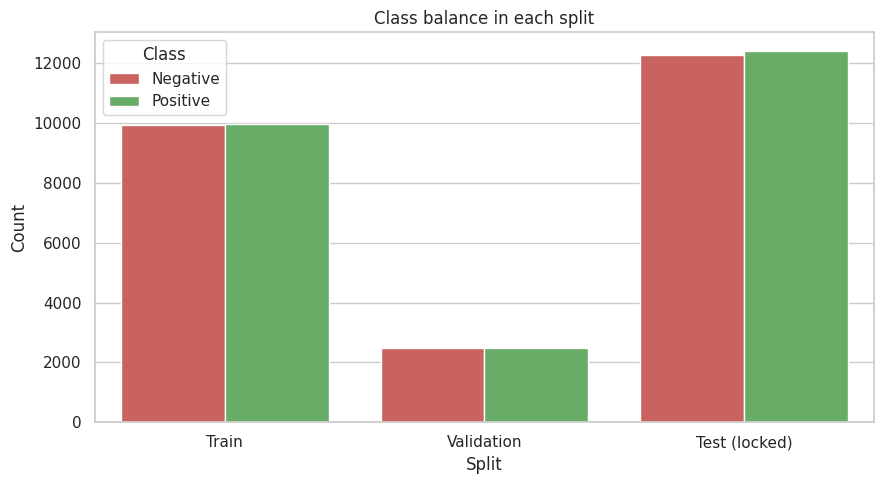

In [ ]:
idx_tr, idx_val = train_test_split(train_df.index, test_size=0.2, stratify=train_df["label"], random_state=SEED)
y_tr, y_val = train_df.loc[idx_tr, "label"], train_df.loc[idx_val, "label"]
y_test = test_df["label"]

split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test (locked)"],
    "Reviews": [len(idx_tr), len(idx_val), len(test_df)],
    "Negative": [(y_tr == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    "Positive": [(y_tr == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
})
display(split_table)
split_table.to_csv("outputs/table_split_sizes.csv", index=False)

plot_df = split_table.melt(id_vars=["Split", "Reviews"], value_vars=["Negative", "Positive"], var_name="Class", value_name="Count")
sns.barplot(data=plot_df, x="Split", y="Count", hue="Class", palette=["#d9534f", "#5cb85c"])
plt.title("Class balance in each split")
save("01_split_class_balance")

## Phase 4: Does heavy cleaning help? (preprocessing ablation)

In [ ]:
def quick_eval(col):
    pipe = Pipeline([("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)),
                     ("clf", LogisticRegression(max_iter=1000))])
    pipe.fit(train_df.loc[idx_tr, col], y_tr)
    return accuracy_score(y_val, pipe.predict(train_df.loc[idx_val, col]))

acc_light, acc_full = quick_eval("light"), quick_eval("full")
ablation = pd.DataFrame({
    "Text version": ["Light (HTML/URL removal, lowercase, contractions; stopwords kept)",
                     "Full Week 1 pipeline (+ punctuation, stopword removal, lemmatization)"],
    "Validation accuracy": [acc_light, acc_full],
})
display(ablation.round(4))
ablation.to_csv("outputs/table_preprocessing_ablation.csv", index=False)

TEXT_COL = "light" if acc_light >= acc_full else "full"
print(f"\nText version used from here on: {TEXT_COL.upper()}")

,Text version,Validation accuracy
0,"Light (HTML/URL removal, lowercase, contractio...",0.8904
1,"Full Week 1 pipeline (+ punctuation, stopword ...",0.8944



Text version used from here on: FULL


## Phase 5: Feature extraction × algorithm comparison (validation set)


,Features,Model,Accuracy,Precision,Recall,F1,Fit time (s)
0,TF-IDF (uni+bigrams),Linear SVM,0.9004,0.8909,0.9130,0.9018,10.1
1,TF-IDF (uni+bigrams),Logistic Regression,0.8944,0.8826,0.9102,0.8962,12.2
2,TF-IDF (unigrams),Logistic Regression,0.8910,0.8792,0.9070,0.8929,3.6
3,TF-IDF (uni+bigrams),Naive Bayes,0.8846,0.8834,0.8866,0.8850,10.3
4,TF-IDF (unigrams),Linear SVM,0.8838,0.8760,0.8946,0.8852,3.4
5,BoW (unigram counts),Logistic Regression,0.8707,0.8660,0.8778,0.8718,9.3
6,TF-IDF (unigrams),Naive Bayes,0.8649,0.8743,0.8529,0.8635,3.0
7,BoW (unigram counts),Naive Bayes,0.8498,0.8662,0.8281,0.8467,4.9
8,BoW (unigram counts),Linear SVM,0.8458,0.8423,0.8517,0.8470,6.9
9,-,Majority-class baseline,0.5009,0.5009,1.0000,0.6675,0.0


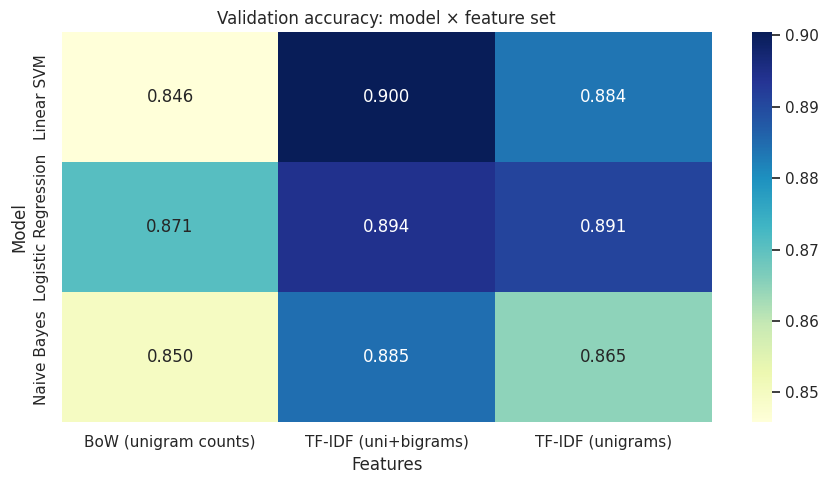

In [ ]:
X_tr, X_val = train_df.loc[idx_tr, TEXT_COL], train_df.loc[idx_val, TEXT_COL]

vec_factories = {
    "BoW (unigram counts)": lambda: CountVectorizer(min_df=5),
    "TF-IDF (unigrams)": lambda: TfidfVectorizer(min_df=5, sublinear_tf=True),
    "TF-IDF (uni+bigrams)": lambda: TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True),
}
model_factories = {
    "Naive Bayes": lambda: MultinomialNB(),
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000),
    "Linear SVM": lambda: LinearSVC(),
}

records = []
base = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
records.append({"Features": "-", "Model": "Majority-class baseline", **metrics(y_val, base.predict(X_val)), "Fit time (s)": 0.0})

for vname, vf in vec_factories.items():
    for mname, mf in model_factories.items():
        t0 = time.time()
        pipe = Pipeline([("vec", vf()), ("clf", mf())]).fit(X_tr, y_tr)
        pred = pipe.predict(X_val)
        records.append({"Features": vname, "Model": mname, **metrics(y_val, pred), "Fit time (s)": round(time.time() - t0, 1)})

comparison = pd.DataFrame(records).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(comparison.round(4))
comparison.to_csv("outputs/table_model_comparison.csv", index=False)

pivot = comparison[comparison["Features"] != "-"].pivot(index="Model", columns="Features", values="Accuracy")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Validation accuracy: model × feature set")
save("02_model_comparison_heatmap")

In [ ]:
# Optional: a small neural network (MLP) on TF-IDF features (about 1-3 minutes)
t0 = time.time()
mlp = Pipeline([("vec", TfidfVectorizer(min_df=5, sublinear_tf=True, max_features=20000)),
                ("clf", MLPClassifier(hidden_layer_sizes=(64,), early_stopping=True, max_iter=30, random_state=SEED))])
mlp.fit(X_tr, y_tr)
mlp_res = {"Features": "TF-IDF (20k unigrams)", "Model": "Neural network (MLP, 64 units)",
           **metrics(y_val, mlp.predict(X_val)), "Fit time (s)": round(time.time() - t0, 1)}
display(pd.DataFrame([mlp_res]).round(4))
pd.DataFrame([mlp_res]).to_csv("outputs/table_mlp_validation.csv", index=False)

,Features,Model,Accuracy,Precision,Recall,F1,Fit time (s)
0,TF-IDF (20k unigrams),"Neural network (MLP, 64 units)",0.8988,0.8863,0.9154,0.9006,63.8


## Phase 6: Hyperparameter tuning with 5-fold cross-validation


Naive Bayes: done in 104s
Logistic Regression: done in 109s
Linear SVM: done in 102s


,Model,Best parameters,CV accuracy (mean),CV accuracy (std),Validation accuracy,Time (s)
0,Naive Bayes,{'alpha': 0.3},0.8819,0.0038,0.8822,104.2
1,Logistic Regression,{'C': 10},0.8965,0.0080,0.9010,108.9
2,Linear SVM,{'C': 0.3},0.8973,0.0083,0.9034,101.8



Selected model (best mean CV accuracy): Linear SVM


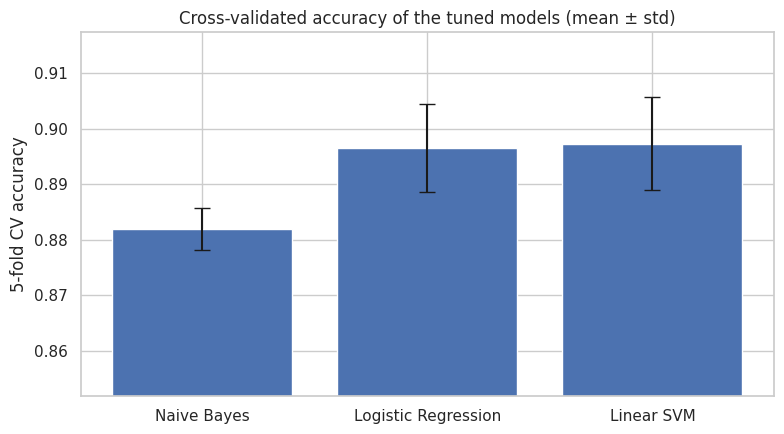

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def tfidf12():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)

grids = {
    "Naive Bayes": (MultinomialNB(), {"clf__alpha": [0.1, 0.3, 1.0]}),
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"clf__C": [1, 3, 10]}),
    "Linear SVM": (LinearSVC(), {"clf__C": [0.1, 0.3, 1.0]}),
}

tuned, rows = {}, []
for name, (est, grid) in grids.items():
    t0 = time.time()
    gs = GridSearchCV(Pipeline([("vec", tfidf12()), ("clf", est)]), grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    tuned[name] = gs.best_estimator_
    rows.append({"Model": name, "Best parameters": str({k.replace("clf__", ""): v for k, v in gs.best_params_.items()}),
                 "CV accuracy (mean)": gs.best_score_,
                 "CV accuracy (std)": gs.cv_results_["std_test_score"][gs.best_index_],
                 "Validation accuracy": accuracy_score(y_val, gs.best_estimator_.predict(X_val)),
                 "Time (s)": round(time.time() - t0, 1)})
    print(f"{name}: done in {time.time() - t0:.0f}s")

tuning = pd.DataFrame(rows)
display(tuning.round(4))
tuning.to_csv("outputs/table_tuning_cv.csv", index=False)

best_name = tuning.sort_values("CV accuracy (mean)", ascending=False).iloc[0]["Model"]
print("\nSelected model (best mean CV accuracy):", best_name)

plt.figure(figsize=(8, 4.5))
plt.bar(tuning["Model"], tuning["CV accuracy (mean)"], yerr=tuning["CV accuracy (std)"], capsize=6, color="#4c72b0")
plt.ylim(tuning["CV accuracy (mean)"].min() - 0.03, min(1.0, tuning["CV accuracy (mean)"].max() + 0.02))
plt.ylabel("5-fold CV accuracy")
plt.title("Cross-validated accuracy of the tuned models (mean ± std)")
save("03_tuning_cv_scores")

## Phase 7: Final evaluation on the locked test set


In [ ]:
X_full, y_full = train_df[TEXT_COL], train_df["label"]
X_test = test_df[TEXT_COL]

def get_scores(m, X):
    return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X)

final_models, preds, scores, rows = {}, {}, {}, []
for name, est in tuned.items():
    m = clone(est).fit(X_full, y_full)
    final_models[name] = m
    preds[name], scores[name] = m.predict(X_test), get_scores(m, X_test)
    rows.append({"Model": name, **metrics(y_test, preds[name]), "ROC-AUC": roc_auc_score(y_test, scores[name])})

# baselines
dummy = DummyClassifier(strategy="most_frequent").fit(X_full, y_full)
rows.append({"Model": "Majority-class baseline", **metrics(y_test, dummy.predict(X_test)), "ROC-AUC": 0.5})

sia = SentimentIntensityAnalyzer()
v_scores = test_df["text"].map(lambda t: sia.polarity_scores(strip_html(t))["compound"])
v_pred = (v_scores >= 0).astype(int)
preds["VADER (baseline)"], scores["VADER (baseline)"] = v_pred, v_scores
rows.append({"Model": "VADER (rule-based baseline)", **metrics(y_test, v_pred), "ROC-AUC": roc_auc_score(y_test, v_scores)})

test_results = pd.DataFrame(rows)
display(test_results.round(4))
test_results.to_csv("outputs/table_test_results.csv", index=False)

print(f"\nSelected model (by CV): {best_name}")
print(classification_report(y_test, preds[best_name], target_names=["negative", "positive"], digits=3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Naive Bayes,0.8653,0.8833,0.8436,0.8630,0.9412
1,Logistic Regression,0.8955,0.8996,0.8917,0.8957,0.9610
2,Linear SVM,0.8979,0.9004,0.8961,0.8983,0.9619
3,Majority-class baseline,0.5030,0.5030,1.0000,0.6693,0.5000
4,VADER (rule-based baseline),0.6997,0.6518,0.8649,0.7434,0.7873



Selected model (by CV): Linear SVM
              precision    recall  f1-score   support

    negative      0.895     0.900     0.898     12266
    positive      0.900     0.896     0.898     12412

    accuracy                          0.898     24678
   macro avg      0.898     0.898     0.898     24678
weighted avg      0.898     0.898     0.898     24678



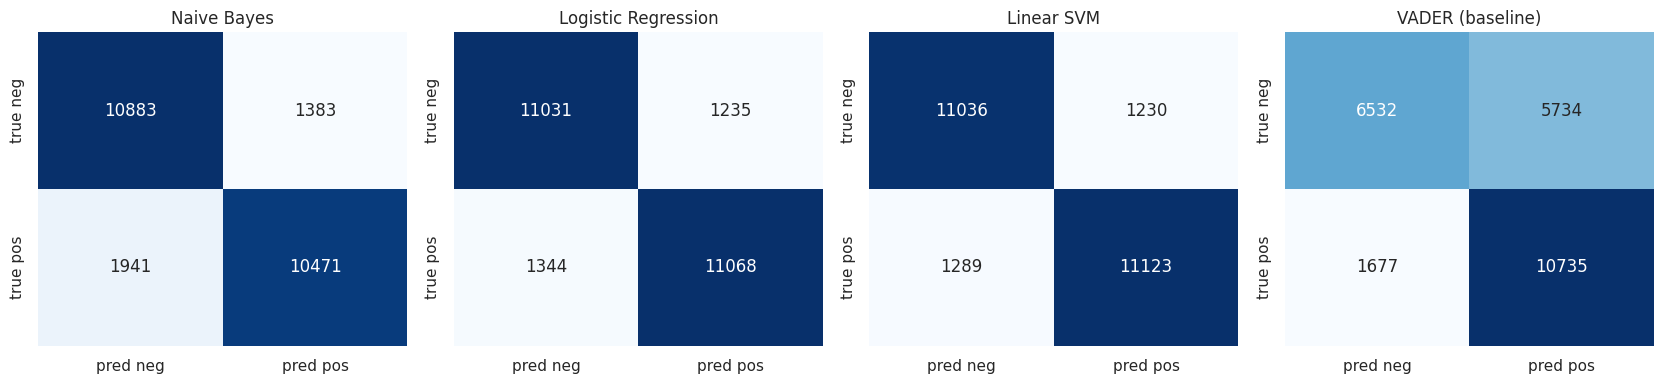

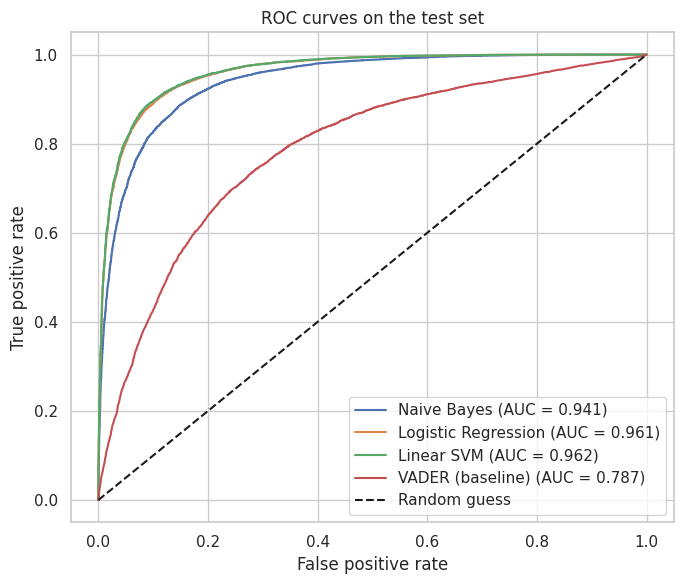

In [ ]:
# Confusion matrices and ROC curves
names = list(tuned) + ["VADER (baseline)"]
fig, axes = plt.subplots(1, len(names), figsize=(4.2 * len(names), 4))
for ax, n in zip(axes, names):
    cm = confusion_matrix(y_test, preds[n])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred neg", "pred pos"], yticklabels=["true neg", "true pos"])
    ax.set_title(n)
save("04_test_confusion_matrices")

plt.figure(figsize=(7, 6))
for n in names:
    fpr, tpr, _ = roc_curve(y_test, scores[n])
    plt.plot(fpr, tpr, label=f"{n} (AUC = {roc_auc_score(y_test, scores[n]):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves on the test set"); plt.legend(loc="lower right")
save("05_roc_curves")

## Phase 8: Error analysis


In [ ]:
sel_pred = preds[best_name]
err = test_df.assign(pred=sel_pred, score=scores[best_name])
wrong = err[err["label"] != err["pred"]]
print(f"Selected model errors: {len(wrong)} of {len(err)} ({len(wrong) / len(err):.1%})")
print("False negatives (true positive, predicted negative):", int(((err.label == 1) & (err.pred == 0)).sum()))
print("False positives (true negative, predicted positive):", int(((err.label == 0) & (err.pred == 1)).sum()))

for title, subset in [("FALSE NEGATIVES", wrong[wrong.label == 1]), ("FALSE POSITIVES", wrong[wrong.label == 0])]:
    print(f"\n===== {title} (3 random examples) =====")
    for _, r in subset.sample(min(3, len(subset)), random_state=SEED).iterrows():
        print(f"[model score: {r['score']:.2f}] {strip_html(r['text'])[:350]}...\n")

Selected model errors: 2519 of 24678 (10.2%)
False negatives (true positive, predicted negative): 1289
False positives (true negative, predicted positive): 1230

===== FALSE NEGATIVES (3 random examples) =====
[model score: -0.61] Some users are confused about the identity of the armed men walking down the steps in the "Odessa staircase" sequence. These men are not Cossacks but regular army troops.  The Cossacks arrive at the scene a little later and they are the men on horses slashing at the crowd with their sabers.  To experts on Russian history: Correct me on this if I'm ...

[model score: -1.23] Simon Wests pg-13 thriller about a babysitter who gets disturbing prank calls while sitting at a mansion is neither original nor exciting enough to be called a good film. Although there are some elements of suspense, good eye candy and decent characters, the film is just another I know what you did last summer, as it falls short of being taken seri...

[model score: -0.44] Most people are t

,Length bucket,Accuracy,Reviews
0,< 100 words,0.9028,3096
1,100-200,0.9005,11627
2,200-400,0.8928,6863
3,> 400 words,0.8949,3092


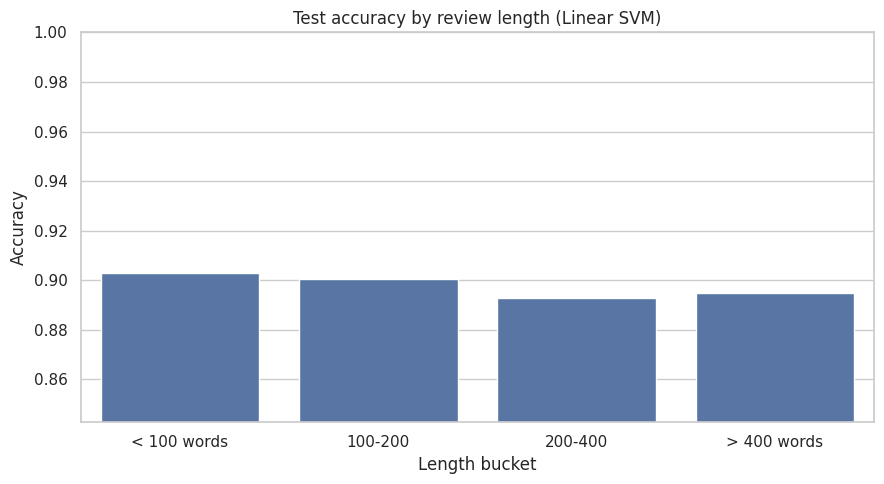

In [ ]:
# Error rate by review length
err["words"] = err["text"].str.split().str.len()
err["correct"] = (err["label"] == err["pred"])
err["Length bucket"] = pd.cut(err["words"], bins=[0, 100, 200, 400, 100000], labels=["< 100 words", "100-200", "200-400", "> 400 words"])
by_len = err.groupby("Length bucket", observed=False)["correct"].agg(["mean", "count"]).reset_index()
by_len.columns = ["Length bucket", "Accuracy", "Reviews"]
display(by_len.round(4))
by_len.to_csv("outputs/table_accuracy_by_length.csv", index=False)

sns.barplot(data=by_len, x="Length bucket", y="Accuracy", color="#4c72b0")
plt.ylim(by_len["Accuracy"].min() - 0.05, 1.0)
plt.title(f"Test accuracy by review length ({best_name})")
save("07_accuracy_by_length")

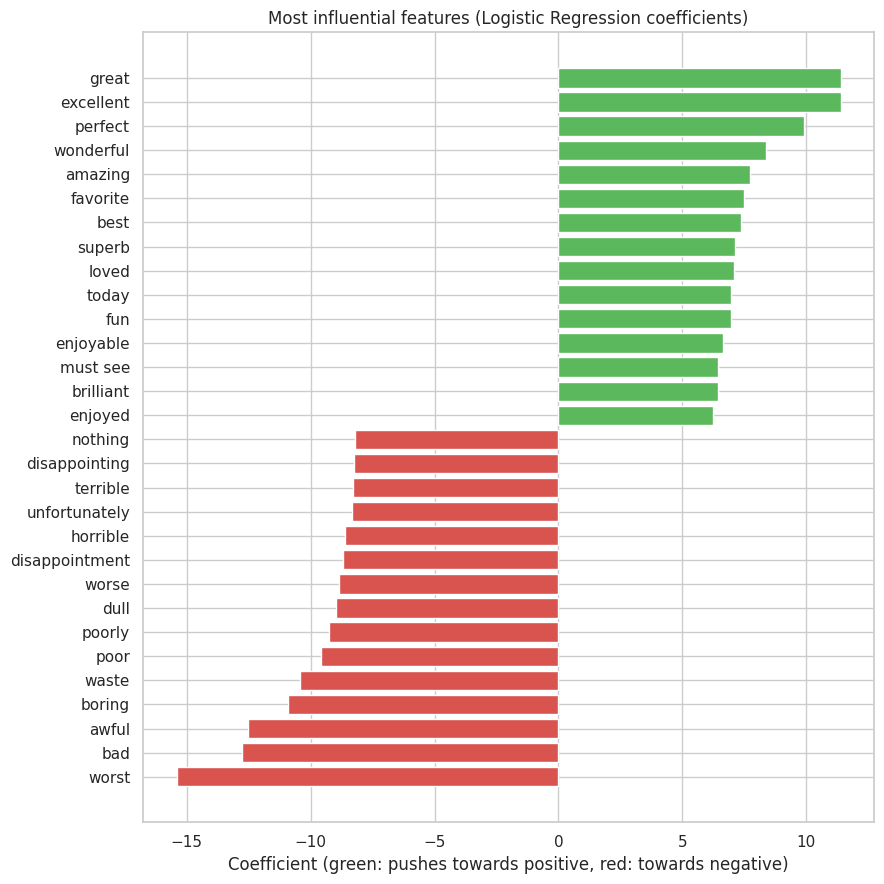

In [ ]:
# What did Logistic Regression learn? (largest positive and negative coefficients)
lr = final_models["Logistic Regression"]
feat_names = lr.named_steps["vec"].get_feature_names_out()
coef = lr.named_steps["clf"].coef_[0]
order = np.argsort(coef)
top = list(order[:15]) + list(order[-15:])

plt.figure(figsize=(9, 9))
plt.barh([feat_names[i] for i in top], coef[top], color=["#d9534f" if coef[i] < 0 else "#5cb85c" for i in top])
plt.title("Most influential features (Logistic Regression coefficients)")
plt.xlabel("Coefficient (green: pushes towards positive, red: towards negative)")
save("06_top_features")

## Phase 9: Learning curve (does more data help?)


,Training reviews,Validation accuracy
0,1992,0.8486
1,4980,0.8749
2,9961,0.8896
3,14942,0.8988
4,19923,0.9034


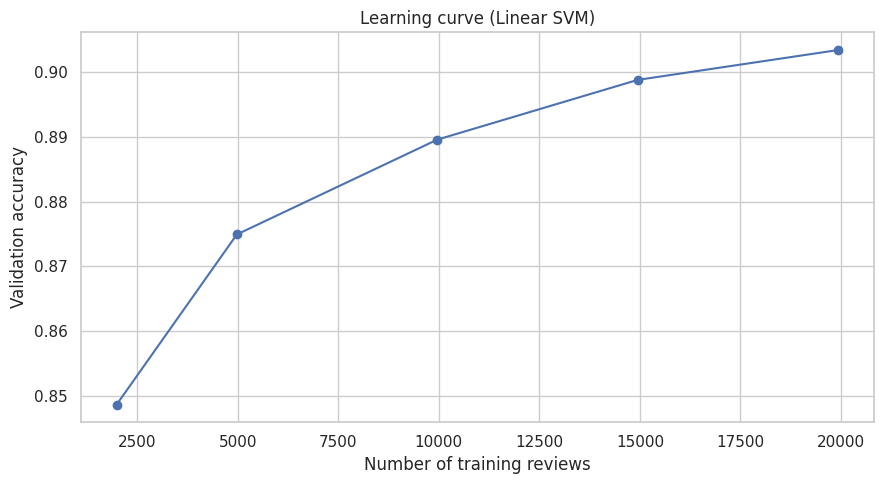

In [ ]:
fracs = [0.1, 0.25, 0.5, 0.75, 1.0]
lc = []
for f in fracs:
    sub = idx_tr[: int(len(idx_tr) * f)]
    m = clone(tuned[best_name]).fit(train_df.loc[sub, TEXT_COL], train_df.loc[sub, "label"])
    lc.append({"Training reviews": len(sub), "Validation accuracy": accuracy_score(y_val, m.predict(X_val))})
lc = pd.DataFrame(lc)
display(lc.round(4))
lc.to_csv("outputs/table_learning_curve.csv", index=False)

plt.plot(lc["Training reviews"], lc["Validation accuracy"], marker="o")
plt.xlabel("Number of training reviews"); plt.ylabel("Validation accuracy")
plt.title(f"Learning curve ({best_name})")
save("08_learning_curve")

## Export and versions

In [ ]:
import importlib.metadata as md
print("Python:", sys.version.split()[0])
for lib in ["scikit-learn", "pandas", "numpy", "nltk", "datasets", "vaderSentiment", "matplotlib", "seaborn"]:
    print(lib, md.version(lib))      # put these in your report appendix

Python: 3.13.15
scikit-learn 1.6.1
pandas 2.2.3
numpy 2.1.3
nltk 3.9.1
datasets 4.8.5
vaderSentiment 3.3.2
matplotlib 3.10.0
seaborn 0.13.2


In [ ]:
import shutil
shutil.make_archive("classification_outputs", "zip", "outputs")
try:
    from google.colab import files
    files.download("classification_outputs.zip")
except ImportError:
    print("Not running in Colab: find classification_outputs.zip in the working folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>